# 04 — Nvidia Markets: Filter & Deep Dive

**Source:** `data_processed/markets_enriched.json` (3,385 enriched markets)

## Structure

**Section 1** — List all Nvidia-related markets from the dataset, grouped by event type.

**Section 2** — Deep dive into the market *"Will NVIDIA be the largest company in the world by market cap on December 31?"*, exploring all four local data sources: `book/`, `price/`, `trade/`, `holder/`.

In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

ENRICHED_PATH = Path("data_processed/markets_enriched.json")
DATASET_DIR   = Path("data/Polymarket_dataset/Polymarket_dataset")

markets = json.load(open(ENRICHED_PATH))
print(f"Total markets loaded: {len(markets)}")

Total markets loaded: 3385


## Section 1 — All Nvidia Markets

Filter all markets whose `question` field contains "nvidia" (case-insensitive), then group them by event type.

In [20]:
nvidia_markets = [m for m in markets if "nvidia" in m.get("question", "").lower()]
print(f"Nvidia markets found: {len(nvidia_markets)}")
for m in sorted(nvidia_markets, key=lambda m: m['question']):
    print(f"  [{m['market_id']}] {m['question']}")

Nvidia markets found: 16
  [557945] Will NVIDIA be the largest company in the world by market cap on August 31?
  [516818] Will NVIDIA be the largest company in the world by market cap on December 31?
  [577996] Will anyone say "Automotive" during the Q2 2025 Nvidia earnings call?
  [577992] Will anyone say "China" during the Q2 2025 Nvidia earnings call?
  [578000] Will anyone say "Cosmos" during the Q2 2025 Nvidia earnings call?
  [577991] Will anyone say "Datacenter" during the Q2 2025 Nvidia earnings call?
  [577988] Will anyone say "Enterprise" during the Q2 2025 Nvidia earnings call?
  [577989] Will anyone say "Gaming" during the Q2 2025 Nvidia earnings call?
  [577998] Will anyone say "Hopper" during the Q2 2025 Nvidia earnings call?
  [577990] Will anyone say "Inference" during the Q2 2025 Nvidia earnings call?
  [577994] Will anyone say "Networking" during the Q2 2025 Nvidia earnings call?
  [577999] Will anyone say "Omniverse" during the Q2 2025 Nvidia earnings call?
  [57799

In [4]:
# Group by event type
earnings = [m for m in nvidia_markets if "earnings call" in m.get("question", "").lower()]
largest  = [m for m in nvidia_markets if "largest company" in m.get("question", "").lower()]
other    = [m for m in nvidia_markets if m not in earnings and m not in largest]

print(f"Type A — Largest company : {len(largest)} markets")
print(f"Type B — Earnings call   : {len(earnings)} markets")
if other:
    print(f"Other                    : {len(other)} markets")


def market_summary_df(markets_list: list) -> pd.DataFrame:
    rows = []
    for m in markets_list:
        outcomes   = m.get('outcomes', [])
        prices     = m.get('outcomePrices', [])
        resolution = dict(zip(outcomes, prices)) if outcomes and prices else {}
        rows.append({
            'market_id':  m['market_id'],
            'question':   m['question'],
            'startDate':  (m.get('startDate') or '')[:10],
            'endDate':    (m.get('endDate') or '')[:10],
            'volume ($)': f"{float(m.get('volume') or 0):,.0f}",
            'closed':     m.get('closed'),
            'resolution': str(resolution),
        })
    return pd.DataFrame(rows).sort_values('endDate').reset_index(drop=True)

Type A — Largest company : 2 markets
Type B — Earnings call   : 14 markets


In [5]:
print("=== Type A: Largest Company by Market Cap ===")
display(market_summary_df(largest))

=== Type A: Largest Company by Market Cap ===


,market_id,question,startDate,endDate,volume ($),closed,resolution
0,557945,Will NVIDIA be the largest company in the worl...,2025-06-30,2025-08-31,"419,391",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
1,516818,Will NVIDIA be the largest company in the worl...,2024-12-30,2025-12-31,"9,158,407",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."


In [6]:
print("=== Type B: Q2 2025 Nvidia Earnings Call Buzzwords ===")
df_earnings = market_summary_df(earnings)
# Extract the keyword from the question for readability
df_earnings["keyword"] = df_earnings["question"].str.extract(r'say \\"(.*?)\\"')
display(df_earnings[["market_id","keyword","endDate","volume ($)","closed","resolution"]])

=== Type B: Q2 2025 Nvidia Earnings Call Buzzwords ===


,market_id,keyword,endDate,volume ($),closed,resolution
0,577999,NaN,2025-08-27,"2,121",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
1,577992,NaN,2025-08-27,"13,155",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
2,577996,NaN,2025-08-27,"7,342",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
3,578000,NaN,2025-08-27,"1,617",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
4,578001,NaN,2025-08-27,"3,281",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
5,577997,NaN,2025-08-27,"8,078",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
6,577990,NaN,2025-08-27,"14,774",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
7,577995,NaN,2025-08-27,"4,607",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
8,577991,NaN,2025-08-27,"22,013",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."
9,577993,NaN,2025-08-27,"1,852",True,"{'[': '[', '""': '""', 'Y': '1', 'e': '""', 's': ..."


---

## Section 2 — Deep Dive: "Will NVIDIA be the largest company in the world by market cap on December 31?"

**market_id:** 516818 | **volume:** ~$9.15M | **resolved:** Yes (NVIDIA was #1 on Dec 31, 2025)

The local dataset contains four data subfolders for this market. We explore each one below.

In [7]:
TARGET_ID  = "516818"
target     = next(m for m in nvidia_markets if m['market_id'] == TARGET_ID)
cid        = target['conditionId']
market_dir = DATASET_DIR / f"market={cid}"

print(f"Question  : {target['question']}")
print(f"conditionId: {cid}")
print(f"Start date: {target.get('startDate','')[:10]}")
print(f"End date  : {target.get('endDate','')[:10]}")
print(f"Volume    : ${float(target.get('volume',0)):,.0f}")
print(f"Outcomes  : {target.get('outcomes')} -> {target.get('outcomePrices')}")
print(f"Closed    : {target.get('closed')}")
print(f"\nLocal dir : {market_dir}")
print(f"Exists    : {market_dir.exists()}")

Question  : Will NVIDIA be the largest company in the world by market cap on December 31?
conditionId: 0x0b16eb7741855ca3d4383fabb8b760c897c2165d603916497f484b87ba9826dc
Start date: 2024-12-30
End date  : 2025-12-31
Volume    : $9,158,407
Outcomes  : ["Yes", "No"] -> ["1", "0"]
Closed    : True

Local dir : data\Polymarket_dataset\Polymarket_dataset\market=0x0b16eb7741855ca3d4383fabb8b760c897c2165d603916497f484b87ba9826dc
Exists    : True


In [8]:
def parse_first_json(path) -> dict:
    """Parse only the first JSON object from a space-concatenated NDJSON file."""
    content = path.read_text()
    obj, _ = json.JSONDecoder().raw_decode(content.lstrip())
    return obj


def parse_all_json(path) -> list:
    """Parse all JSON objects from a space-concatenated NDJSON file."""
    content = path.read_text().lstrip()
    decoder = json.JSONDecoder()
    records, pos = [], 0
    while pos < len(content):
        remaining = content[pos:]
        stripped  = remaining.lstrip()
        if not stripped:
            break
        obj, end = decoder.raw_decode(stripped)
        records.append(obj)
        pos += len(remaining) - len(stripped) + end
    return records

### 2.1 Book

The `book/` folder contains **2 files** (one per outcome token). Each file holds multiple space-concatenated JSON objects; the first object gives the token's identity metadata.

In [9]:
book_files = sorted((market_dir / "book").glob("token=*.ndjson"))
print(f"Book files: {len(book_files)}")

for f in book_files:
    obj = parse_first_json(f)
    print(f"\n-- {f.name}")
    for k, v in obj.items():
        print(f"   {k:20s}: {v}")

Book files: 2

-- token=69263280792958981516606123639467754139758192236863611059536531765186180114584.ndjson
   token_id            : 69263280792958981516606123639467754139758192236863611059536531765186180114584
   conditionId         : 0x0b16eb7741855ca3d4383fabb8b760c897c2165d603916497f484b87ba9826dc
   market_id           : 516818
   capture_ts_ms       : 1755717165953
   best_bid            : 0.01
   best_ask            : 0.99
   mid                 : 0.5
   spread_bps          : 9898.9898989899
   bid_depth           : 200000.0
   ask_depth           : 1400000.0
   imbalance           : -0.75
   timestamp_ms        : 1755714236285

-- token=94850533403292240972948844256810904078895883844462287088135166537739765648754.ndjson
   token_id            : 94850533403292240972948844256810904078895883844462287088135166537739765648754
   conditionId         : 0x0b16eb7741855ca3d4383fabb8b760c897c2165d603916497f484b87ba9826dc
   market_id           : 516818
   capture_ts_ms       : 175571716

### 2.2 Price

The `price/` folder contains **1–2 files** (one per outcome token). Each file is a sequence of space-concatenated JSON objects with fields:

| field | meaning |
|---|---|
| `t` | Unix timestamp (seconds) |
| `p` | Implied probability (0–1) |
| `outcome_index` | 0 = Yes, 1 = No |
| `token_id` | Token identifier |

In [23]:
price_files = sorted((market_dir / "price").glob("token=*.ndjson"))
print(f"Price files: {len(price_files)}")

dfs = []
for f in price_files:
    records = parse_all_json(f)
    df = pd.DataFrame(records)
    df["dt"] = pd.to_datetime(df["t"], unit="s", utc=True)
    dfs.append(df)
    print(f"  {f.name}: {len(records)} records")

price_df = pd.concat(dfs, ignore_index=True).sort_values('dt')
yes_df   = price_df[price_df['outcome_index'] == 0].copy()
no_df    = price_df[price_df['outcome_index'] == 1].copy()

print(f"\nPrice records — Yes: {len(yes_df)}, No: {len(no_df)}")
print(f"Date range: {price_df['dt'].min().date()} -> {price_df['dt'].max().date()}")
display(price_df[["dt", "p"]].head(5))

Price files: 1
  token=69263280792958981516606123639467754139758192236863611059536531765186180114584.ndjson: 249 records

Price records — Yes: 0, No: 249
Date range: 2025-07-20 -> 2025-08-20


,dt,p
0,2025-07-20 21:00:07+00:00,0.375
1,2025-07-21 00:00:07+00:00,0.375
2,2025-07-21 03:00:07+00:00,0.375
3,2025-07-21 06:00:08+00:00,0.365
4,2025-07-21 09:00:08+00:00,0.350


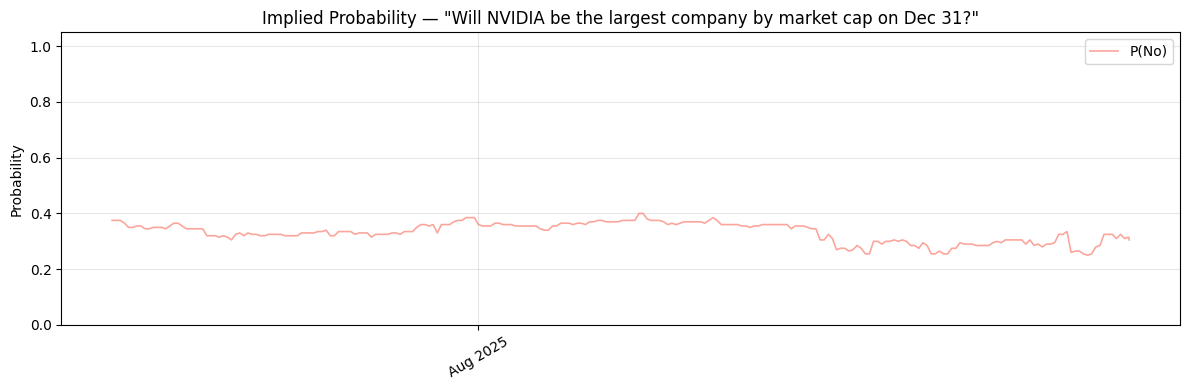

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))

if not yes_df.empty:
    ax.plot(yes_df["dt"], yes_df["p"], label="P(Yes)", color="steelblue", linewidth=1.2)
if not no_df.empty:
    ax.plot(no_df["dt"],  no_df["p"],  label="P(No)",  color="salmon",    linewidth=1.2, alpha=0.7)

ax.set_title('Implied Probability — "Will NVIDIA be the largest company by market cap on Dec 31?"')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Trade

The `trade/` folder contains **1 file** with all individual trades (both tokens). Each record:

| field | meaning |
|---|---|
| `timestamp` | Unix timestamp (seconds) |
| `side` | `"BUY"` or `"SELL"` |
| `price` | Trade price (0–1) |
| `size` | Position size in shares |
| `outcome` | `"Yes"` or `"No"` |
| `asset` | Token ID |

In [12]:
trade_files = sorted((market_dir / "trade").glob("*.ndjson"))
print(f"Trade files: {len(trade_files)}")

trade_records = []
for f in trade_files:
    trade_records.extend(parse_all_json(f))

trade_df = pd.DataFrame(trade_records)
trade_df["dt"]    = pd.to_datetime(trade_df["timestamp"], unit="s", utc=True)
trade_df["size"]  = trade_df["size"].astype(float)
trade_df["price"] = trade_df["price"].astype(float)

print(f"Total trades : {len(trade_df)}")
print(f"Date range   : {trade_df['dt'].min().date()} -> {trade_df['dt'].max().date()}")
print(f"Columns      : {list(trade_df.columns)}")
display(trade_df[["dt", "side", "outcome", "price", "size"]].head(10))

Trade files: 1
Total trades : 1500
Date range   : 2025-08-01 -> 2025-08-20
Columns      : ['conditionId', 'market_id', 'asset', 'timestamp', 'side', 'price', 'size', 'outcome', 'outcomeIndex', 'dt']


,dt,side,outcome,price,size
0,2025-08-20 19:01:35+00:00,SELL,No,0.32,13.00
1,2025-08-20 19:01:35+00:00,BUY,No,0.32,13.00
2,2025-08-20 19:01:35+00:00,BUY,No,0.32,13.00
3,2025-08-20 19:01:35+00:00,BUY,Yes,0.68,13.00
4,2025-08-20 19:01:19+00:00,BUY,No,0.32,7.00
5,2025-08-20 19:01:19+00:00,BUY,Yes,0.68,7.00
6,2025-08-20 17:36:23+00:00,BUY,Yes,0.69,0.47
7,2025-08-20 17:36:23+00:00,BUY,Yes,0.69,80.00
8,2025-08-20 17:36:23+00:00,BUY,No,0.31,0.47
9,2025-08-20 17:36:23+00:00,BUY,No,0.31,80.00


In [13]:
summary = (
    trade_df.groupby(["outcome", "side"])
    .agg(count=("size", "count"), total_size=("size", "sum"), avg_price=("price", "mean"))
    .round(4)
)
display(summary)

count  total_size  avg_price
outcome side                              
No      BUY     457  24811.5515     0.3029
        SELL    130   5697.0496     0.3048
Yes     BUY     583  41230.0651     0.6827
        SELL    330  22340.5632     0.6919

### 2.4 Holder

The `holder/` folder contains **1 file** with top holders per outcome token at snapshot time (2025-08-20).

In [14]:
holder_files = sorted((market_dir / "holder").glob("*.ndjson"))
print(f"Holder files: {len(holder_files)}")

holder_records = []
for f in holder_files:
    holder_records.extend(parse_all_json(f))

holder_df = pd.DataFrame(holder_records)
print(f"Holder records : {len(holder_df)}")
print(f"Columns        : {list(holder_df.columns)}")
display(holder_df.head(20))

Holder files: 1
Holder records : 2
Columns        : ['conditionId', 'token_id', 'holders', 'capture_ts_ms']


,conditionId,token_id,holders,capture_ts_ms
0,0x0b16eb7741855ca3d4383fabb8b760c897c2165d6039...,9485053340329224097294884425681090407889588384...,[{'proxyWallet': '0x8a4c788f043023b8b28a762216...,1755717166155
1,0x0b16eb7741855ca3d4383fabb8b760c897c2165d6039...,6926328079295898151660612363946775413975819223...,[{'proxyWallet': '0xa5ef39c3d3e10d0b270233af41...,1755717166156
